In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

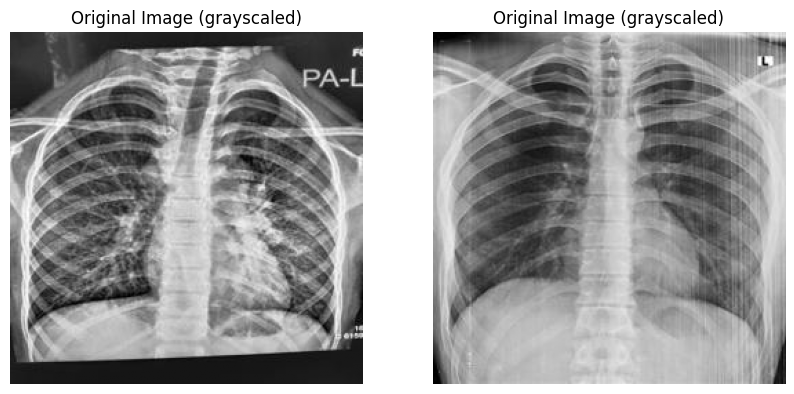

In [54]:
tb_image = cv2.imread('./tb-xray/TB.340.JPG')
tb_image_gray = cv2.cvtColor(tb_image, cv2.COLOR_BGR2GRAY)

normal_image = cv2.imread('./normal-xray/normal.JPG')
normal_image_gray = cv2.cvtColor(normal_image, cv2.COLOR_BGR2GRAY)

# Display the original grayscale images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(tb_image_gray, cmap='gray')
plt.title('Original Image (grayscaled)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(normal_image_gray, cmap='gray')
plt.title('Original Image (grayscaled)')
plt.axis('off')
plt.show()

In [55]:
# Kernel
kernel_sobel_x = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                            [-1, 0, 1]])

kernel_sobel_y = np.array([[-1, -2, -1],
                           [0, 0, 0],
                            [1, 2, 1]])

kernel_roberts_x = np.array([[1, 0],
                            [0, -1]])

kernel_roberts_y = np.array([[0, 1],
                            [-1, 0]])

kernel_prewitt_x = np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]])

kernel_prewitt_y = np.array([[-1, -1, -1],
                            [0, 0, 0],
                            [1, 1, 1]])

kernel_laplacian = np.array([[0, 1, 0],
                            [1, -4, 1],
                            [0, 1, 0]]) 

In [56]:
# Metode

def gaussianblur(image, kernel_size=5, sigma=1):
    gaussian_kernel = cv2.getGaussianKernel(kernel_size, sigma)
    gaussian_kernel = gaussian_kernel @ gaussian_kernel.T
    blurred_image = cv2.filter2D(image, cv2.CV_64F, gaussian_kernel)
    return blurred_image

def roberts_edge_detection(image):
    edge_x = cv2.filter2D(image, cv2.CV_64F, kernel_roberts_x)
    edge_y = cv2.filter2D(image, cv2.CV_64F, kernel_roberts_y)
    edge_magnitude = np.sqrt(edge_x**2 + edge_y**2)
    return edge_magnitude

def sobel_edge_detection(image):
    edge_x = cv2.filter2D(image, cv2.CV_64F, kernel_sobel_x)
    edge_y = cv2.filter2D(image, cv2.CV_64F, kernel_sobel_y)
    edge_magnitude = np.sqrt(edge_x**2 + edge_y**2)
    return edge_magnitude

def prewitt_edge_detection(image):
    edge_x = cv2.filter2D(image, cv2.CV_64F, kernel_prewitt_x)
    edge_y = cv2.filter2D(image, cv2.CV_64F, kernel_prewitt_y)
    edge_magnitude = np.sqrt(edge_x**2 + edge_y**2)
    return edge_magnitude

def laplace_of_gaussian(image):
    blurred_image = gaussianblur(image)

    edge_laplacian = cv2.filter2D(blurred_image, cv2.CV_64F, kernel_laplacian)

    #absolute
    edge_laplacian = np.abs(edge_laplacian)

    return edge_laplacian

def canny_edge_detection(image):
    # Smoothing dengan gaussian
    gaussian_blur = gaussianblur(image)

    # Menghitung gradien
    gradient_x = sobel_edge_detection(gaussian_blur)
    gradient_y = sobel_edge_detection(gaussian_blur)
    gradient_magnitude = np.sqrt(gradient_x**2 + gradient_y**2)
    gradient_direction = np.arctan2(gradient_y, gradient_x) * (180. / np.pi)
    gradient_direction[gradient_direction < 0] += 180

    # Non-maximum suppression
    non_max_suppressed = np.zeros_like(gradient_magnitude)
    for i in range(1, gradient_magnitude.shape[0] - 1):
        for j in range(1, gradient_magnitude.shape[1] - 1):
            direction = gradient_direction[i, j]
            if (0 <= direction < 22.5) or (157.5 <= direction <= 180):
                neighbors = [gradient_magnitude[i, j + 1], gradient_magnitude[i, j - 1]]
            elif (22.5 <= direction < 67.5):
                neighbors = [gradient_magnitude[i + 1, j - 1], gradient_magnitude[i - 1, j + 1]]
            elif (67.5 <= direction < 112.5):
                neighbors = [gradient_magnitude[i + 1, j], gradient_magnitude[i - 1, j]]
            else:
                neighbors = [gradient_magnitude[i - 1, j - 1], gradient_magnitude[i + 1, j + 1]]

            if (gradient_magnitude[i, j] >= neighbors[0]) and (gradient_magnitude[i, j] >= neighbors[1]):
                non_max_suppressed[i, j] = gradient_magnitude[i, j]
    
    # Double Treshold
    edge = np.zeros_like(non_max_suppressed)
    strong_i, strong_j = np.where(non_max_suppressed >= 80)
    zeros_i, zeros_j = np.where(non_max_suppressed < 30)
    edge[strong_i, strong_j] = 255
    edge[zeros_i, zeros_j] = 0
    
    return edge

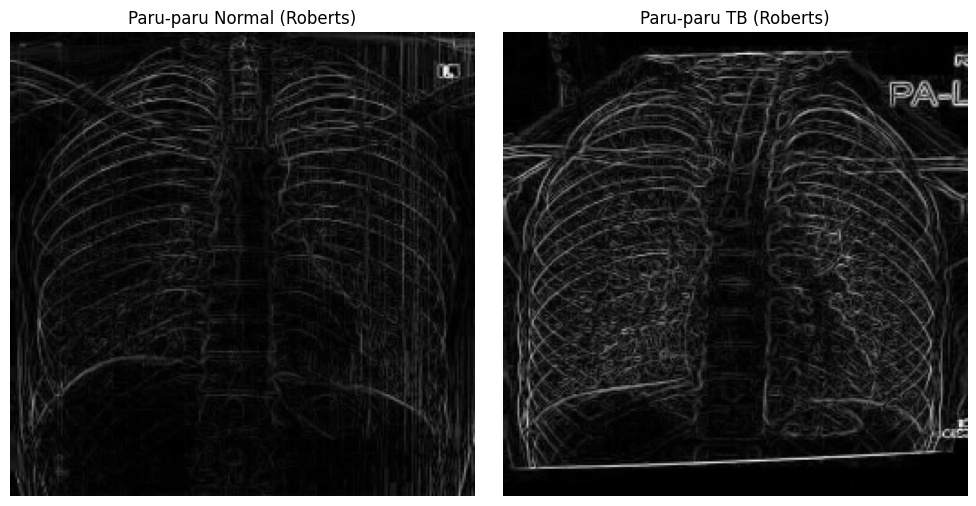

In [57]:
# --- 1. Roberts Edge Detection ---
roberts_normal = roberts_edge_detection(normal_image_gray)
roberts_tb = roberts_edge_detection(tb_image_gray)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(roberts_normal, cmap='gray')
plt.title('Paru-paru Normal (Roberts)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(roberts_tb, cmap='gray')
plt.title('Paru-paru TB (Roberts)')
plt.axis('off')

plt.tight_layout()
plt.show()

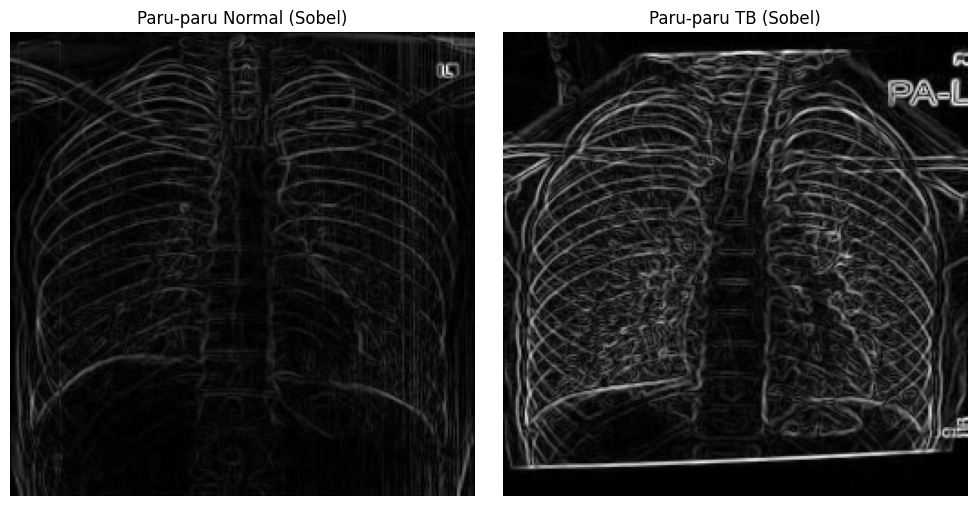

In [58]:
# --- 2. Sobel Edge Detection ---
sobel_normal = sobel_edge_detection(normal_image_gray)
sobel_tb = sobel_edge_detection(tb_image_gray)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sobel_normal, cmap='gray')
plt.title('Paru-paru Normal (Sobel)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel_tb, cmap='gray')
plt.title('Paru-paru TB (Sobel)')
plt.axis('off')

plt.tight_layout()
plt.show()

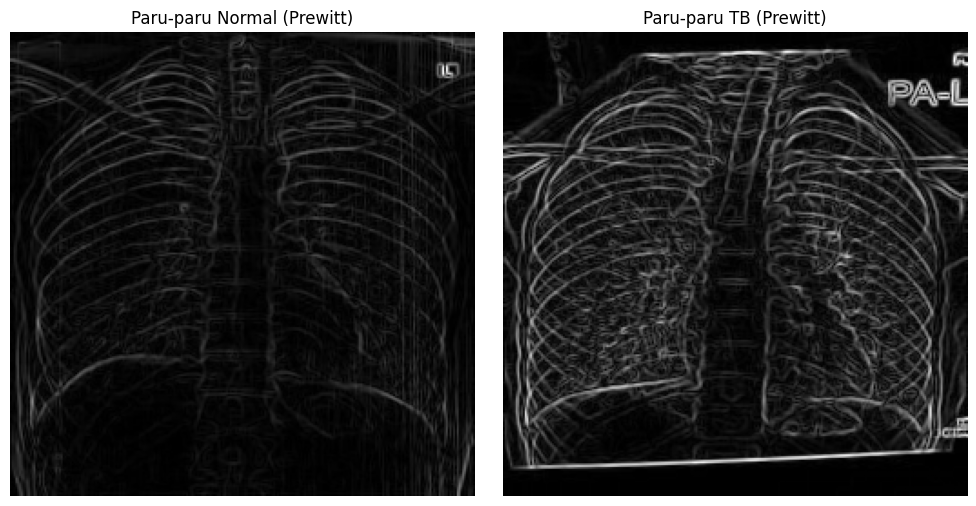

In [59]:
# --- 3. Prewitt Edge Detection ---
prewitt_normal = prewitt_edge_detection(normal_image_gray)
prewitt_tb = prewitt_edge_detection(tb_image_gray)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(prewitt_normal, cmap='gray')
plt.title('Paru-paru Normal (Prewitt)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(prewitt_tb, cmap='gray')
plt.title('Paru-paru TB (Prewitt)')
plt.axis('off')

plt.tight_layout()
plt.show()

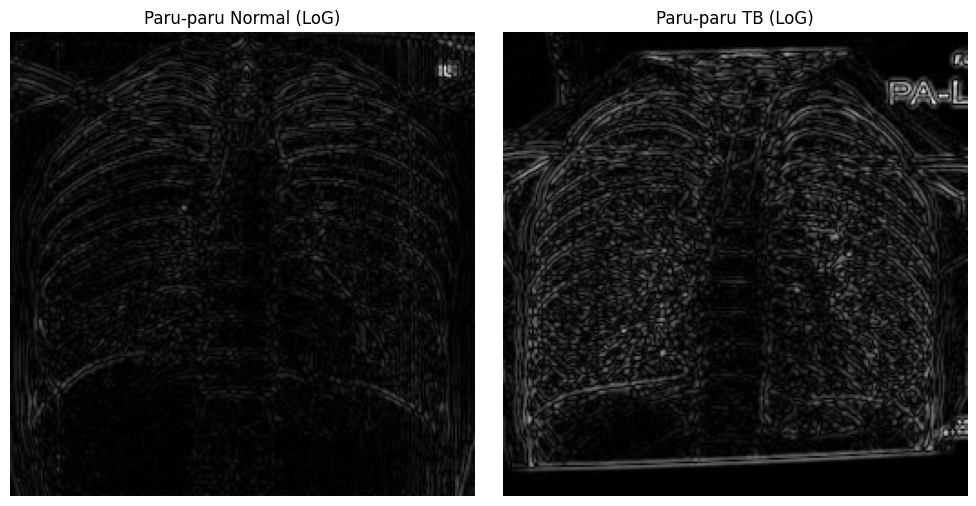

In [60]:
# --- 4. LoG (Laplacian of Gaussian) Edge Detection ---
log_normal = laplace_of_gaussian(normal_image_gray)
log_tb = laplace_of_gaussian(tb_image_gray)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(log_normal, cmap='gray')
plt.title('Paru-paru Normal (LoG)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(log_tb, cmap='gray')
plt.title('Paru-paru TB (LoG)')
plt.axis('off')

plt.tight_layout()
plt.show()

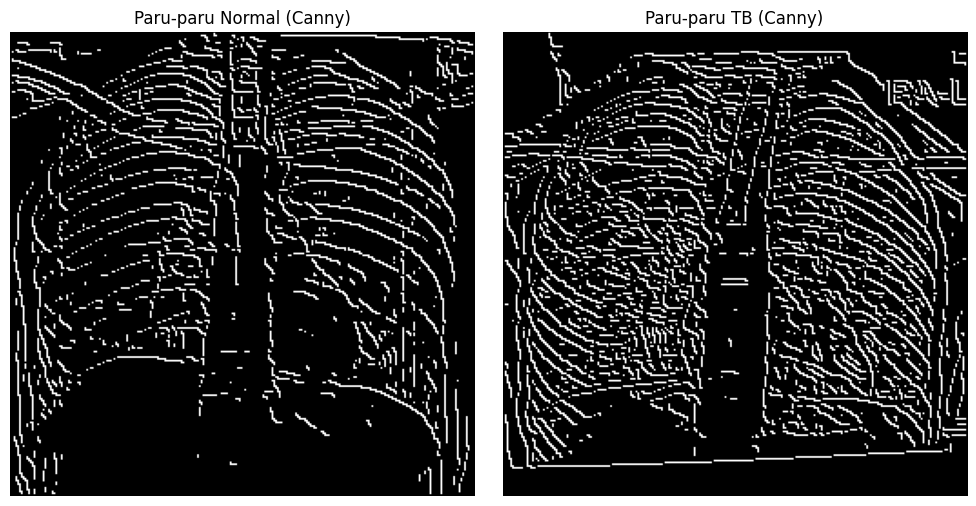

In [61]:
# --- 5. Canny Edge Detection ---
canny_normal = canny_edge_detection(normal_image_gray)
canny_tb = canny_edge_detection(tb_image_gray)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(canny_normal, cmap='gray')
plt.title('Paru-paru Normal (Canny)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(canny_tb, cmap='gray')
plt.title('Paru-paru TB (Canny)')
plt.axis('off')

plt.tight_layout()
plt.show()

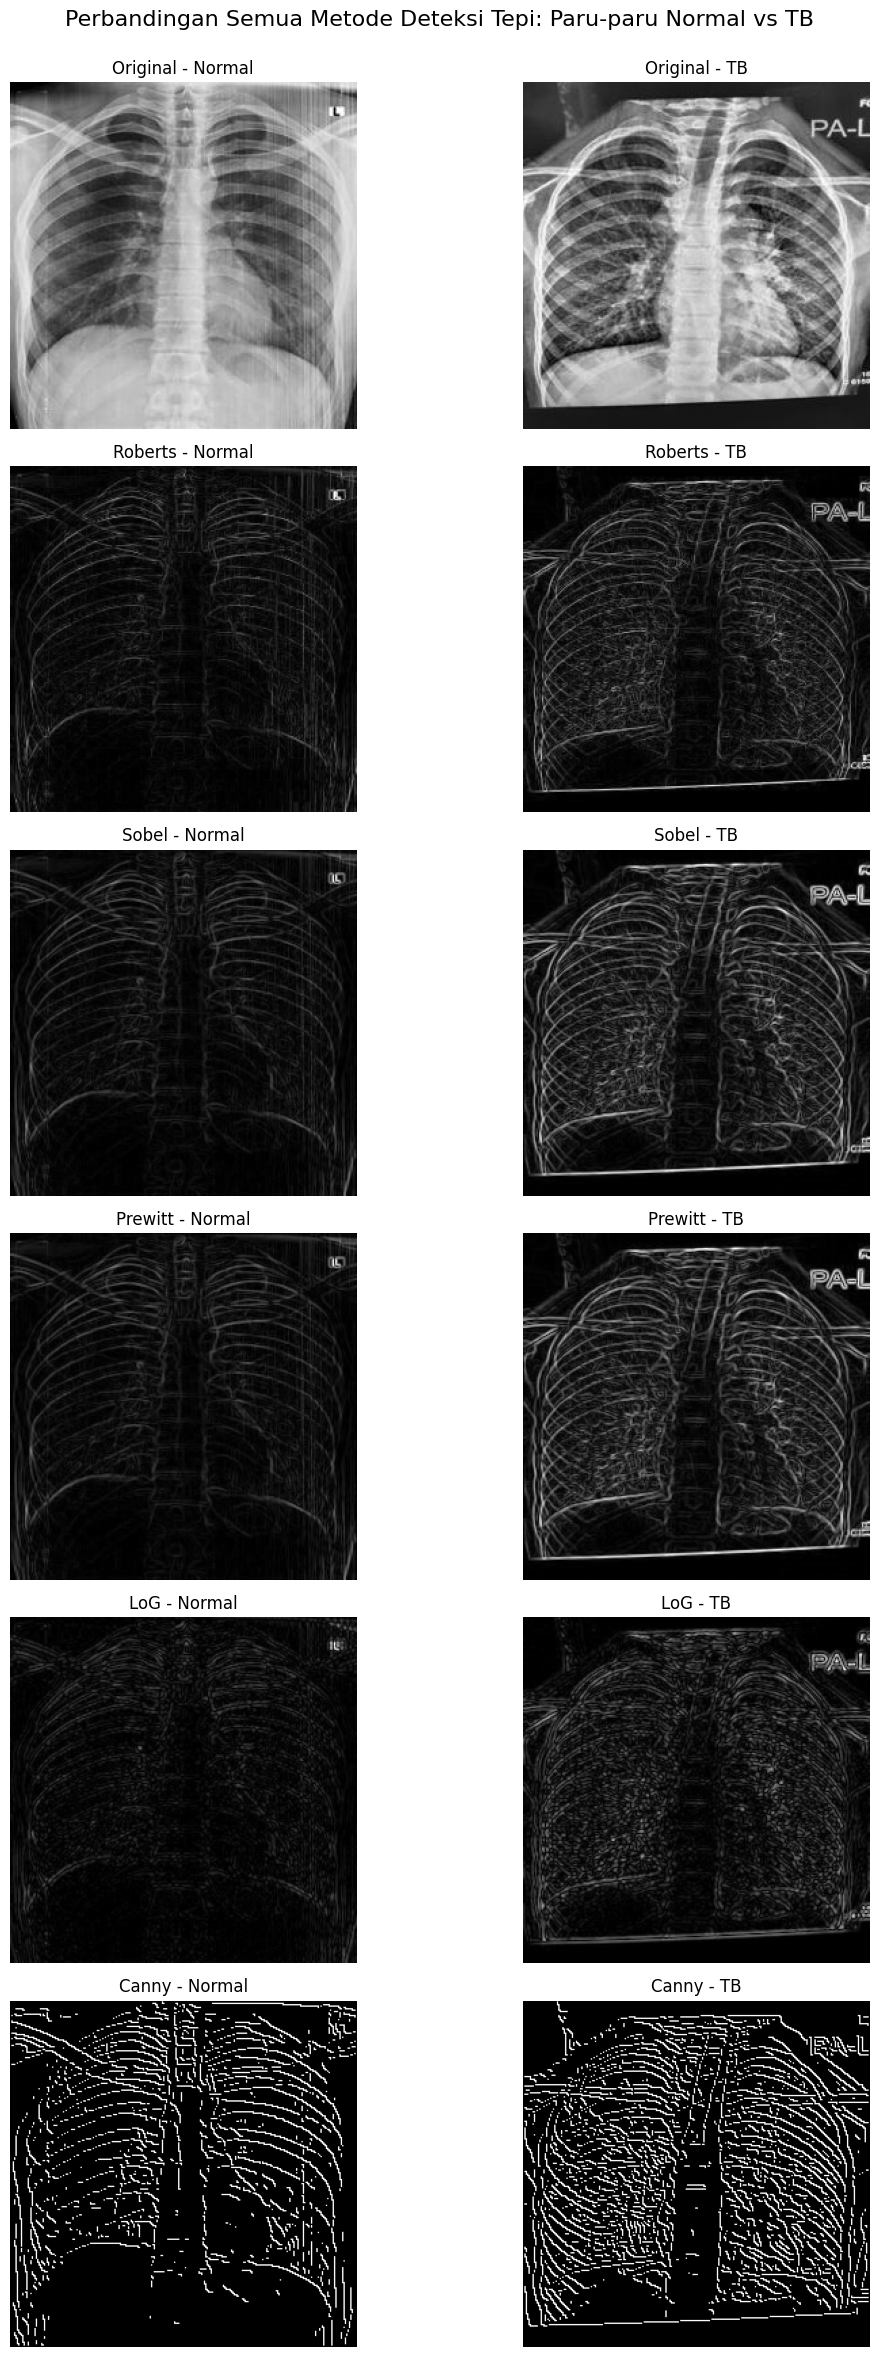

In [62]:
# --- Gabungan Semua Metode (Normal vs TB) ---
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
fig.suptitle('Perbandingan Semua Metode Deteksi Tepi: Paru-paru Normal vs TB', fontsize=16)

# Original
axes[0, 0].imshow(normal_image_gray, cmap='gray')
axes[0, 0].set_title('Original - Normal')
axes[0, 0].axis('off')
axes[0, 1].imshow(tb_image_gray, cmap='gray')
axes[0, 1].set_title('Original - TB')
axes[0, 1].axis('off')

# Roberts
axes[1, 0].imshow(roberts_normal, cmap='gray')
axes[1, 0].set_title('Roberts - Normal')
axes[1, 0].axis('off')
axes[1, 1].imshow(roberts_tb, cmap='gray')
axes[1, 1].set_title('Roberts - TB')
axes[1, 1].axis('off')

# Sobel
axes[2, 0].imshow(sobel_normal, cmap='gray')
axes[2, 0].set_title('Sobel - Normal')
axes[2, 0].axis('off')
axes[2, 1].imshow(sobel_tb, cmap='gray')
axes[2, 1].set_title('Sobel - TB')
axes[2, 1].axis('off')

# Prewitt
axes[3, 0].imshow(prewitt_normal, cmap='gray')
axes[3, 0].set_title('Prewitt - Normal')
axes[3, 0].axis('off')
axes[3, 1].imshow(prewitt_tb, cmap='gray')
axes[3, 1].set_title('Prewitt - TB')
axes[3, 1].axis('off')

# LoG
axes[4, 0].imshow(log_normal, cmap='gray')
axes[4, 0].set_title('LoG - Normal')
axes[4, 0].axis('off')
axes[4, 1].imshow(log_tb, cmap='gray')
axes[4, 1].set_title('LoG - TB')
axes[4, 1].axis('off')

# Canny
axes[5, 0].imshow(canny_normal, cmap='gray')
axes[5, 0].set_title('Canny - Normal')
axes[5, 0].axis('off')
axes[5, 1].imshow(canny_tb, cmap='gray')
axes[5, 1].set_title('Canny - TB')
axes[5, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()